In [1]:
import numpy as np
import pandas as pd
import datetime
import random
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from scipy import stats
import bokeh
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource
import sklearn
from sklearn.linear_model import LinearRegression
import os

In [2]:
path = (r"C:\Suren\Academmics\6th sem\AI & EDGE COMPUTING\Lab\Data Sets\Week 12-15\PET_PRI_GND_DCUS_NUS_W.csv")
df = pd.read_csv(path, delimiter=',')
df.shape

(1361, 14)

In [5]:
df.head(5)

,Date,A1,A2,A3,R1,R2,R3,M1,M2,M3,P1,P2,P3,D1
0,01/02/1995,1.127,1.104,1.231,1.079,1.063,1.167,1.170,1.159,1.298,1.272,1.250,1.386,1.104
1,01/09/1995,1.134,1.111,1.232,1.086,1.070,1.169,1.177,1.164,1.300,1.279,1.256,1.387,1.102
2,01/16/1995,1.126,1.102,1.231,1.078,1.062,1.169,1.168,1.155,1.299,1.271,1.249,1.385,1.100
3,01/23/1995,1.132,1.110,1.226,1.083,1.068,1.165,1.177,1.165,1.296,1.277,1.256,1.378,1.095
4,01/30/1995,1.131,1.109,1.221,1.083,1.068,1.162,1.176,1.163,1.291,1.275,1.255,1.370,1.090


In [7]:
df_diesel = df.drop(columns=['A1',
                             'A2',
                             'A3',
                             'R1',
                             'R2',
                             'R3',
                             'M1',
                             'M2',
                             'M3',
                             'P1',
                             'P2',
                             'P3'])

df_diesel.head(3)

,Date,D1
0,01/02/1995,1.104
1,01/09/1995,1.102
2,01/16/1995,1.100


In [9]:
df_diesel.rename(columns={'D1': 'Diesel'}, inplace=True)

In [11]:
df_diesel.dtypes

Date       object
Diesel    float64
dtype: object

In [13]:
df_diesel['Date'] = pd.to_datetime(df_diesel['Date'])

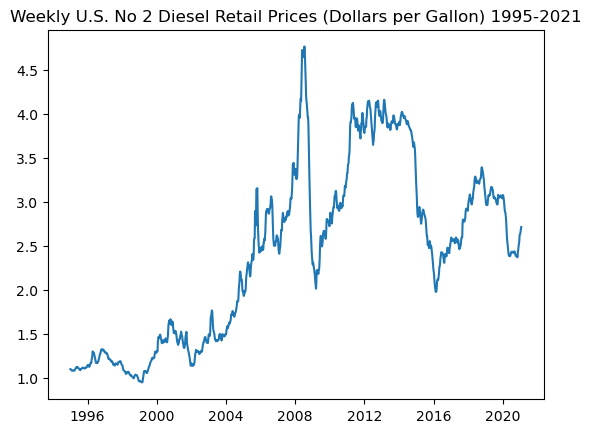

In [15]:
title = 'Weekly U.S. No 2 Diesel Retail Prices (Dollars per Gallon) 1995-2021'

import datetime
import random
import matplotlib.pyplot as plt

col1 = 'Diesel'
col2 = 'Date'

y = df_diesel[col1]
x = df_diesel[col2]

plt.plot(x, y)
plt.gca().set_title(title)
plt.show()

In [17]:
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource

source = ColumnDataSource(df_diesel)
plot = figure(x_axis_type="datetime")

legend_diesel = 'Weekly U.S. No 2 Diesel Retail Prices (Dollars per Gallon) 1995-2021'
plot.line(x='Date', y='Diesel', line_width=1, source=source, color='red', legend_label=legend_diesel)

output_notebook()  # show the output in Jupyter Notebook
show(plot)

Loading BokehJS ...

In [19]:
# format = '%Y-%m-%d'
# substring = string[0:4]

df_diesel['Year'] = 0
df_diesel['Year'] = df_diesel['Date'].dt.strftime('%Y').astype(int)

df_diesel.drop(columns=['Date'])
df_diesel.head(3)

,Date,Diesel,Year
0,1995-01-02,1.104,1995
1,1995-01-09,1.102,1995
2,1995-01-16,1.100,1995


In [21]:
df_year = df_diesel[["Year", "Diesel"]].groupby(["Year"], as_index=False).mean()
df_year.head(10)

,Year,Diesel
0,1995,1.109154
1,1996,1.235283
2,1997,1.198308
3,1998,1.043885
4,1999,1.120519
5,2000,1.490769
6,2001,1.400509
7,2002,1.318750
8,2003,1.509327
9,2004,1.809942


In [23]:
df_year.dtypes

Year        int32
Diesel    float64
dtype: object

Predict Weekly U.S. No 2 Diesel Retail Prices (Dollars per Gallon) 1995-2021
$1.4170382971254725 USD


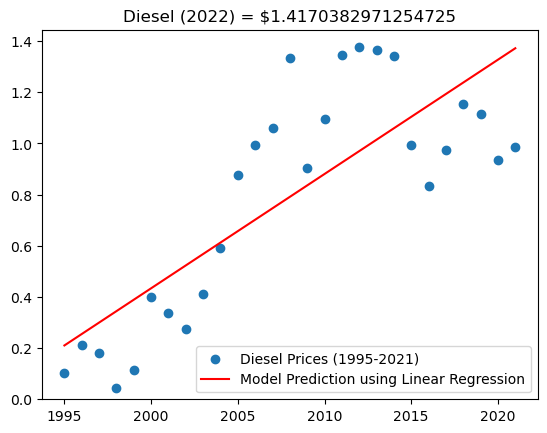

In [25]:
# Variable transformation is a way to make the data work better in your model. Compare before and after.
df_year['Diesel'] = np.log(df_year['Diesel'])
from scipy import stats  # Importing stats module from scipy
x = df_year['Year']  
y = df_year['Diesel']  
# Performing linear regression
slope, intercept, r, p, std_err = stats.linregress(x, y)
# Defining function for prediction
def modelPrediction(x):
    return slope * x + intercept  # Linear equation: y = mx + c
# Label for prediction
label = 'Predict Weekly U.S. No 2 Diesel Retail Prices (Dollars per Gallon) 1995-2021'
# Applying model to all X values
model = list(map(modelPrediction, x))  
# Predicting diesel price for the year 2022
x_pred = 2022  
y_pred = modelPrediction(x_pred)  
# Displaying results
print(label)
round(y_pred, 2)
print('${} USD'.format(y_pred))
# Plotting results
title = 'Diesel (2022) = ${}'.format(y_pred)
plt.title(title)
plt.scatter(x, y, label="Diesel Prices (1995-2021)")  # Scatter plot of actual data
plt.plot(x, model, color='red', label="Model Prediction using Linear Regression")  # Regression line
plt.ylim(ymin=0)  # Ensuring y-axis starts from zero
plt.legend()
plt.show()